# HR Employee Attrition Analysis

**Business question:** Which employees are most likely to leave, and what factors drive attrition?

Dataset: [IBM HR Analytics Employee Attrition & Performance](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)

Before running: download the CSV per `data/README.md` and place it at `data/WA_Fn-UseC_-HR-Employee-Attrition.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 100)

df = pd.read_csv('data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.shape

(1470, 35)

## 1. Clean & prepare

In [2]:
df.info()
df.isna().sum().sum()  # check for missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

np.int64(0)

In [3]:
# Drop columns that are constant / not useful for analysis
constant_cols = [c for c in ['EmployeeCount', 'Over18', 'StandardHours'] if c in df.columns]
df = df.drop(columns=constant_cols)
df.duplicated().sum()

np.int64(0)

## 2. Overall attrition rate

Overall attrition rate: 16.1%


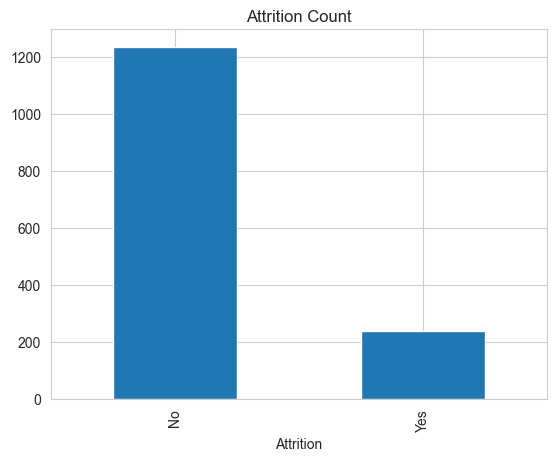

In [4]:
attrition_rate = (df['Attrition'] == 'Yes').mean()
print(f"Overall attrition rate: {attrition_rate:.1%}")

df['Attrition'].value_counts().plot(kind='bar', title='Attrition Count')
plt.savefig('images/attrition_overall.png', bbox_inches='tight')
plt.show()

## 3. Attrition by segment (department, job role, overtime)

In [5]:
for col in ['Department', 'JobRole', 'OverTime', 'MaritalStatus']:
    rate = df.groupby(col)['Attrition'].apply(lambda s: (s == 'Yes').mean()).sort_values(ascending=False)
    print(f"\nAttrition rate by {col}:\n{rate}")


Attrition rate by Department:
Department
Sales                     0.206278
Human Resources           0.190476
Research & Development    0.138398
Name: Attrition, dtype: float64

Attrition rate by JobRole:
JobRole
Sales Representative         0.397590
Laboratory Technician        0.239382
Human Resources              0.230769
Sales Executive              0.174847
Research Scientist           0.160959
Manufacturing Director       0.068966
Healthcare Representative    0.068702
Manager                      0.049020
Research Director            0.025000
Name: Attrition, dtype: float64

Attrition rate by OverTime:
OverTime
Yes    0.305288
No     0.104364
Name: Attrition, dtype: float64

Attrition rate by MaritalStatus:
MaritalStatus
Single      0.255319
Married     0.124814
Divorced    0.100917
Name: Attrition, dtype: float64


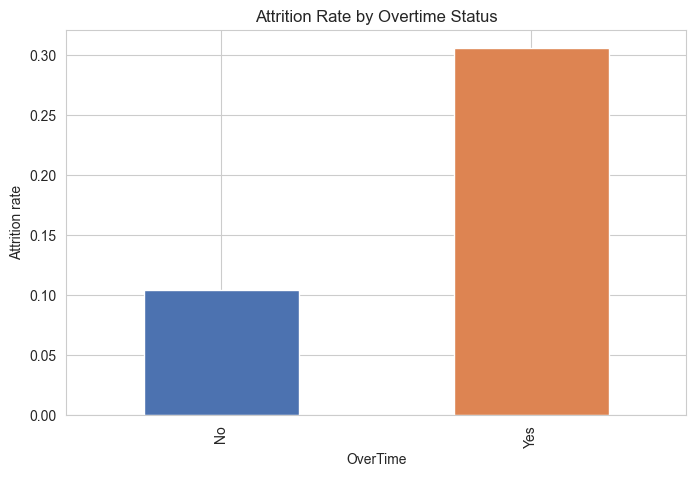

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
df.groupby('OverTime')['Attrition'].apply(lambda s: (s == 'Yes').mean()).plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_ylabel('Attrition rate')
ax.set_title('Attrition Rate by Overtime Status')
plt.savefig('images/attrition_by_overtime.png', bbox_inches='tight')
plt.show()

## 4. Income, tenure, and satisfaction vs. attrition

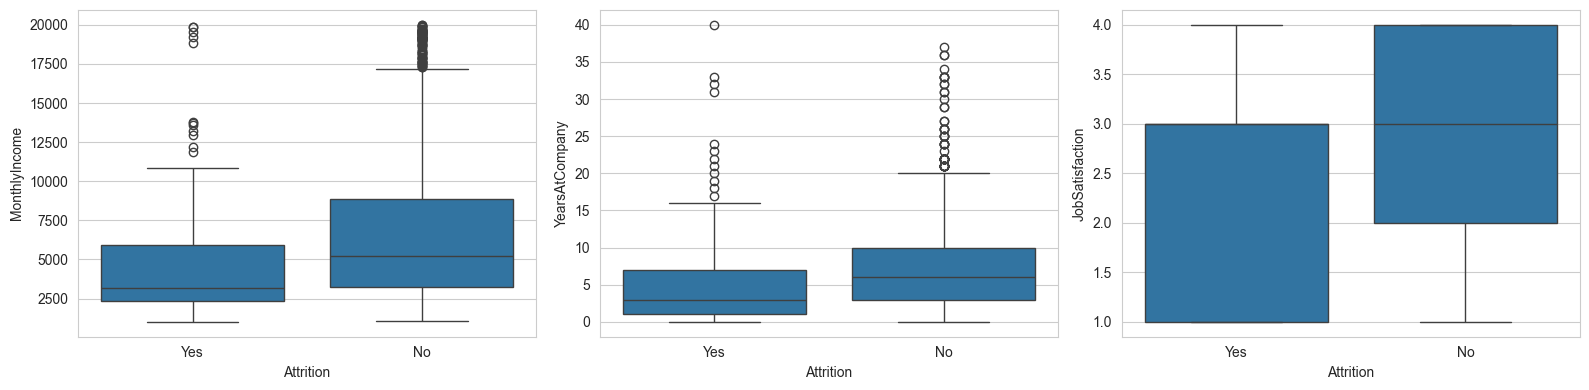

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[0])
sns.boxplot(data=df, x='Attrition', y='YearsAtCompany', ax=axes[1])
sns.boxplot(data=df, x='Attrition', y='JobSatisfaction', ax=axes[2])
plt.tight_layout()
plt.savefig('images/attrition_boxplots.png', bbox_inches='tight')
plt.show()

## 5. Correlation heatmap (numeric features)

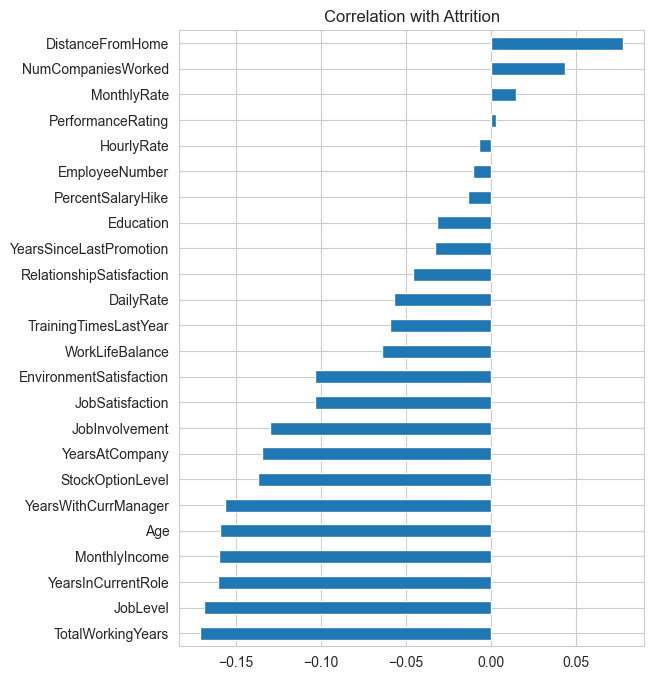

In [8]:
df_num = df.copy()
df_num['Attrition_num'] = (df_num['Attrition'] == 'Yes').astype(int)
corr = df_num.corr(numeric_only=True)['Attrition_num'].drop('Attrition_num').sort_values()

fig, ax = plt.subplots(figsize=(6, 8))
corr.plot(kind='barh', ax=ax)
ax.set_title('Correlation with Attrition')
plt.savefig('images/attrition_correlation.png', bbox_inches='tight')
plt.show()

## 6. Key findings & recommendations

**Findings:**
- Overall attrition rate: **16.1%** (237 of 1,470 employees). No nulls/duplicates in the raw data.
- **OverTime is the strongest single driver** of attrition (r = 0.25, higher than any numeric feature): 30.5% attrition when working overtime vs. 10.4% when not — almost 3x.
- Highest-risk segment: **Sales Representatives working overtime (66.7% attrition, n=24)**; more broadly, overtime + <2 years tenure = 55.1% attrition (n=69).
- By role: Sales Rep (39.8%) and Lab Technician (23.9%) churn most; Manager (4.9%) and Research Director (2.5%) least.
- Leavers are less tenured and lower paid: median income $3,202 vs. $5,204 for stayers; median tenure 3 vs. 6 years. JobSatisfaction does *not* separate leavers from stayers (median 3/4 for both).

**Recommendations:**
1. Cap/compensate overtime, starting in Sales — it's the strongest lever in this dataset.
2. Flag new hires (<2 yrs) who start working overtime as at-risk and intervene early.
3. Revisit entry-level pay for Sales Rep / Lab Technician roles, the highest-churn, lowest-tenure segments.

_(Full detail and business framing in the project [README](./README.md).)_
